# 12 — Calibration (Phase 5)

Two questions, both about whether a number means what it says.

### 1. When the model says 30%, does it flood 30% of the time?

Ranking is all that PR-AUC and threshold selection need, so a model can pass
every Phase 4 check while its probabilities are badly wrong. That stops being
harmless the moment a number leaves the notebook: a CAP message carries a
probability, and an operations room reads "70%" as seventy in a hundred. If it
is really seven, the system is not wrong once — it teaches people to ignore it.

There is a specific reason to expect trouble here. Training used **negative
downsampling** (5% for the general model, 25% for onset), which multiplies the
odds by up to twenty. `correct_for_downsampling` undoes that arithmetically.
This notebook checks whether the correction actually worked.

### 2. Can the depth intervals be repaired?

Phase 4's 90% intervals covered **43–63%** of wet rows. They cannot ship. Three
candidate fixes were listed; this notebook measures all three rather than
choosing on argument.

### A warning about calibrating rare events

At 1 flood in 9,000 rows, almost every predicted probability is near zero and
almost every one is right. Equal-width bins put 99.99% of rows in the first bin
and report near-perfect calibration for a model that has learned nothing. Every
curve here uses **quantile bins** and prints the row and positive count per bin.
A bin holding four positives supports no claim.

### What you need

Notebooks 05–09. About 12 minutes.

## Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_here = Path.cwd()
_root = next(p for p in [_here, *_here.parents] if (p / "config/config.yaml").is_file())
sys.path.insert(0, str(_root / "src"))
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)

from bkkflood.config import load_config
from bkkflood.rawio import connect
from bkkflood.evaluate import folds

CFG = load_config()
FOLDS = folds()
GEN = pd.read_parquet("data/features/model_general_results.parquet")
ONSET = pd.read_parquet("data/features/model_onset_results.parquet")
BASE = pd.read_parquet("data/features/baseline_results.parquet")
con = connect()
print("loaded:", GEN.shape, ONSET.shape, BASE.shape)
from bkkflood.models import build_matrix, train_classifier, train_quantile, score_year
from bkkflood.evaluate import best_threshold, binary_metrics, pr_auc
from bkkflood.calibration import (reliability_curve, expected_calibration_error,
                                  isotonic_fit, apply_isotonic, quantile_coverage,
                                  coverage_verdict)
TIER, H, NR = 15, 1, 0.25
print(f"calibrating at {TIER} cm / {H} h, negative rate {NR}")

loaded: (36, 29) (36, 29) (144, 23)
calibrating at 15 cm / 1 h, negative rate 0.25


## 1. Score the onset model, validation and test

Validation is used to fit the correction. Test is used to judge it. Fitting the
calibration on test would be the same mistake as tuning a threshold there — it
improves the report without improving the system.

In [2]:
fold = FOLDS[-1]
X, y, meta = build_matrix(fold["train"], TIER, H, "onset", NR, con=con)
Xv, yv, _ = build_matrix([fold["val"]], TIER, H, "onset", NR, con=con,
                         columns=meta["features"])
booster = train_classifier(X, y, Xv, yv)

val = score_year(booster, fold["val"], meta["features"], TIER, H, kind="onset",
                 negative_rate=NR, con=con)
test = score_year(booster, fold["test"], meta["features"], TIER, H, kind="onset",
                  negative_rate=NR, con=con)
yv_true = val[f"y_ge{TIER}_{H}h"].fillna(False).to_numpy(bool)
yt_true = test[f"y_ge{TIER}_{H}h"].fillna(False).to_numpy(bool)
print(f"val {len(val):,} rows ({yv_true.sum()} positives) | "
      f"test {len(test):,} rows ({yt_true.sum()} positives)")
print(f"observed rate on test: {yt_true.mean():.6f}  (1 in {1/yt_true.mean():.0f})")

val 3,450,931 rows (251 positives) | test 3,347,490 rows (554 positives)
observed rate on test: 0.000165  (1 in 6042)


## 2. Did the downsampling correction work?

`score` is what LightGBM produced on downsampled data. `prob` is that number
after the odds correction. The second should be close to the observed frequency;
the first should be far too high.

In [3]:
raw = reliability_curve(yt_true, test["score"].to_numpy())
cor = reliability_curve(yt_true, test["prob"].to_numpy())

print("BEFORE correction (raw LightGBM output on downsampled data)")
print(raw[["rows", "positives", "mean_predicted", "observed_rate",
           "over_confidence"]].round(5).to_string(index=False))
print(f"\nECE = {expected_calibration_error(raw):.5f}\n")
print("AFTER the downsampling correction")
print(cor[["rows", "positives", "mean_predicted", "observed_rate",
           "over_confidence"]].round(5).to_string(index=False))
print(f"\nECE = {expected_calibration_error(cor):.5f}")

BEFORE correction (raw LightGBM output on downsampled data)
  rows  positives  mean_predicted  observed_rate  over_confidence
278958          3         0.00001        0.00001          0.82643
278959          0         0.00001        0.00000              NaN
278958          3         0.00002        0.00001          1.54204
278961          0         0.00002        0.00000              NaN
278952          7         0.00003        0.00003          1.01015
278957         10         0.00003        0.00004          0.86690
278957          8         0.00004        0.00003          1.33391
278958          7         0.00005        0.00003          1.90838
278957          9         0.00006        0.00003          1.92956
278958         11         0.00009        0.00004          2.19876
278957         34         0.00014        0.00012          1.15720
278958        462         0.00260        0.00166          1.56789

ECE = 0.00009

AFTER the downsampling correction
  rows  positives  mean_predicte

**Read the `over_confidence` column.** It is predicted divided by observed, so
1.0 is perfect and 20 means the model claims twenty times the real risk. The
downsampling correction should move it decisively toward 1.

`positives` is the column that limits what can be concluded. Bins at the low end
hold no positives at all — nothing can be said about calibration there, and the
ECE quietly averages those bins in as if it could.

## 3. Isotonic calibration on top

The arithmetic correction assumes the only distortion is the sampling. Anything
else — the model being systematically overconfident on hard rows, say — needs a
fitted correction.

Isotonic regression is used rather than Platt scaling because it assumes nothing
about the shape of the distortion. It is monotone **non-decreasing**, which is
almost — but not exactly — ranking-preserving: it maps whole ranges of input onto
a single output, so rows that were previously ordered become tied. PR-AUC can
therefore move by a small amount, and it does here. Recall and precision at a
fixed threshold are unaffected.

Worth watching rather than assuming: the cell below prints PR-AUC before and
after so any larger change is visible.

In [4]:
iso = isotonic_fit(yv_true, val["prob"].to_numpy())
test["prob_iso"] = apply_isotonic(iso, test["prob"].to_numpy())

isoc = reliability_curve(yt_true, test["prob_iso"].to_numpy())
print("AFTER isotonic calibration (fitted on validation)")
print(isoc[["rows", "positives", "mean_predicted", "observed_rate",
            "over_confidence"]].round(5).to_string(index=False))

ece = {"raw score": expected_calibration_error(raw),
       "downsampling-corrected": expected_calibration_error(cor),
       "+ isotonic": expected_calibration_error(isoc)}
print("\nexpected calibration error (lower is better)")
for k, v in ece.items():
    print(f"  {k:24s} {v:.6f}")

# Ranking must be untouched -- verify rather than assert it in prose.
thr = best_threshold(yv_true, val["score"].to_numpy(), metric="f2")["threshold"]
before = binary_metrics(yt_true, test["score"].to_numpy() >= thr)
a = pr_auc(yt_true, test["prob"].to_numpy())
bb = pr_auc(yt_true, test["prob_iso"].to_numpy())
print(f"\nPR-AUC {a:.4f} -> {bb:.4f}  (change {bb-a:+.4f}, from isotonic ties)")
if abs(bb - a) > 0.02:
    print("  WARNING: that is more than tie-breaking. Investigate before using.")

AFTER isotonic calibration (fitted on validation)
   rows  positives  mean_predicted  observed_rate  over_confidence
2240666         39         0.00000        0.00002          0.02305
 341249         10         0.00002        0.00003          0.51559
 452035         37         0.00004        0.00008          0.45674
  66807         10         0.00006        0.00015          0.43085
 246733        458         0.00100        0.00186          0.53644

expected calibration error (lower is better)
  raw score                0.000093
  downsampling-corrected   0.000081
  + isotonic               0.000084

PR-AUC 0.0931 -> 0.0921  (change -0.0010, from isotonic ties)


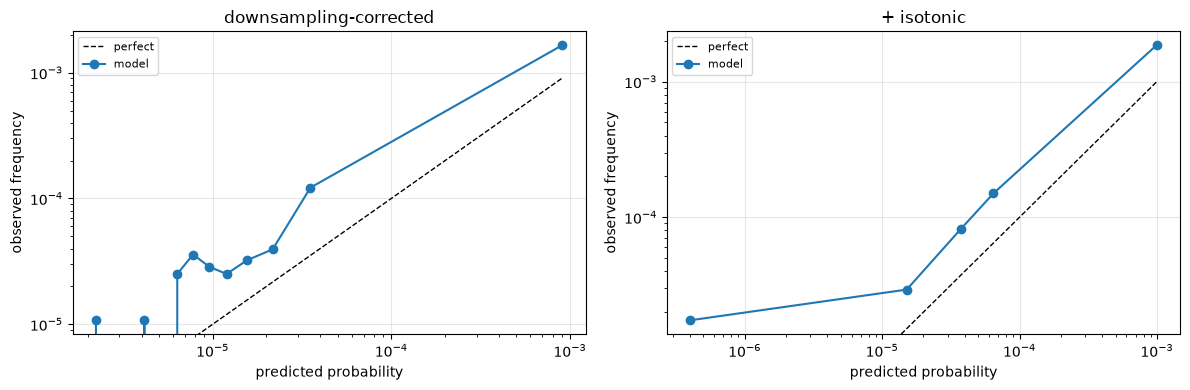

Log scales: at a 1-in-9,000 base rate a linear plot is a dot at the origin.


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (curve, title) in zip(ax, [(cor, "downsampling-corrected"),
                                  (isoc, "+ isotonic")]):
    a.plot([0, curve.mean_predicted.max()], [0, curve.mean_predicted.max()],
           "k--", lw=1, label="perfect")
    a.plot(curve.mean_predicted, curve.observed_rate, marker="o", label="model")
    a.set_xlabel("predicted probability"); a.set_ylabel("observed frequency")
    a.set_title(title); a.set_xscale("log"); a.set_yscale("log")
    a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Log scales: at a 1-in-9,000 base rate a linear plot is a dot at the origin.")

## 4. Repairing the depth intervals

Phase 4's 90% intervals covered 43–63% of wet rows. Three candidate fixes were
listed. Rather than argue, all three are measured on the same fold.

- **as-is** — Phase 4's model, for reference
- **wet rows only** — train on rows where water actually appeared, so the
  overwhelming mass of zeros cannot dominate the loss
- **widened** — keep the model, ask for the 1st/99th percentile instead

The third is the least honest option: it buys coverage by making the interval
say less. It is measured because it might be the only one that works.

In [6]:
ALPHAS = [0.05, 0.95]
WIDE = [0.01, 0.99]
results, preds = [], {}

Xd, yd, dmeta = build_matrix(fold["train"], TIER, H, "general", 0.05, con=con,
                             target="depth")
Xdv, ydv, _ = build_matrix([fold["val"]], TIER, H, "general", 0.05, con=con,
                           columns=dmeta["features"], target="depth")
ok, okv = ~np.isnan(yd), ~np.isnan(ydv)

variants = {
    "as-is (Phase 4)":  (Xd[ok], yd[ok], ALPHAS),
    "wet rows only":    (Xd[ok & (yd > 0)], yd[ok & (yd > 0)], ALPHAS),
    "widened 1/99":     (Xd[ok], yd[ok], WIDE),
}
for name, (Xt, yt_, alphas) in variants.items():
    if len(yt_) < 500:
        print(f"  skip {name}: only {len(yt_)} rows"); continue
    qs = {}
    for a in alphas:
        qs[a] = train_quantile(Xt, yt_, Xdv[okv], ydv[okv], alpha=a)
    preds[name] = (qs, alphas)
    print(f"trained {name}: {len(yt_):,} rows")

trained as-is (Phase 4): 869,176 rows
trained wet rows only: 20,957 rows
trained widened 1/99: 869,176 rows


In [7]:
# Score the test year once, predict every variant from the same matrix.
from bkkflood.config import resolve
path = str(resolve(f"data/features/features_{fold['test']}.parquet"))
feats = dmeta["features"]
keep = ["station_code", "ts", "fl_depth_now", f"y_maxdepth_{H}h"]
sel = ", ".join([f'"{c}"' for c in feats] + [f'"{c}"' for c in keep])
n = con.execute(f"SELECT count(*) FROM '{path}' WHERE y_valid_{H}h").fetchone()[0]

frames = []
for off in range(0, n, 750_000):
    d = con.execute(f"SELECT {sel} FROM '{path}' WHERE y_valid_{H}h "
                    f"LIMIT 750000 OFFSET {off}").fetchdf()
    if d.empty:
        break
    r = d[keep].copy()
    for name, (qs, alphas) in preds.items():
        r[f"{name}|lo"] = np.clip(qs[alphas[0]].predict(
            d[feats], num_iteration=qs[alphas[0]].best_iteration), 0, None)
        r[f"{name}|hi"] = np.clip(qs[alphas[1]].predict(
            d[feats], num_iteration=qs[alphas[1]].best_iteration), 0, None)
    frames.append(r)
D = pd.concat(frames, ignore_index=True)
print(f"scored {len(D):,} rows")

rows = []
for name in preds:
    cov = quantile_coverage(D[f"y_maxdepth_{H}h"], D[f"{name}|lo"], D[f"{name}|hi"])
    v = coverage_verdict(cov)
    rows.append({"variant": name, **{k: cov[k] for k in
                 ("wet_rows", "coverage_all", "coverage_wet",
                  "median_width_wet_cm", "mean_under_cm")},
                 "verdict": v["verdict"], "publishable": v["publishable_as_p95"]})
COV = pd.DataFrame(rows)
print(f"\ntarget {CFG['objective']['quantile_coverage_target']}, "
      f"band {CFG['objective']['quantile_coverage_tolerance']}\n")
print(COV.round(4).to_string(index=False))

scored 3,348,088 rows

target 0.9, band [0.85, 0.93]

        variant  wet_rows  coverage_all  coverage_wet  median_width_wet_cm  mean_under_cm                                                        verdict  publishable
as-is (Phase 4)      5476        0.9992        0.6225               7.0551         6.9615 FAIL — too narrow, understates depth (the dangerous direction)        False
  wet rows only      5476        0.0016        0.9644              23.2792         3.5076                      fail — too wide, honest but uninformative        False
   widened 1/99      5476        0.9996        0.7874              18.3750         6.9860 FAIL — too narrow, understates depth (the dangerous direction)        False


**`mean_under_cm` is the column that matters operationally.** It is the average
amount by which the water exceeded the top of the interval, on the occasions it
did. An interval that is wrong by 2 cm is a nuisance. One that is wrong by 20 cm
sends a crew expecting a puddle.

If no variant is publishable, that is the finding, and depth must be withheld
until BMA supplies data that supports it. Reporting an interval that fails its
own coverage check is worse than reporting no interval, because it will be
believed.

In [8]:
best = COV[COV.publishable]
if len(best):
    pick = best.sort_values("median_width_wet_cm").iloc[0]
    print(f"USABLE: '{pick.variant}' — wet coverage {pick.coverage_wet:.3f}, "
          f"median width {pick.median_width_wet_cm:.1f} cm")
    print("\nUpdate notebook 09 to use this variant and re-run before Phase 10.")
else:
    print("NO SINGLE-STAGE VARIANT PASSES.\n")
    print("But look at WHY each one failed — the two failures are opposite, and")
    print("that points at the fix:\n")
    for _, r in COV.iterrows():
        print(f"  {r.variant:18s} wet {r.coverage_wet:.3f}  all {r.coverage_all:.3f}  "
              f"width {r.median_width_wet_cm:5.1f} cm")
    print()
    print("'wet rows only' covers the wet rows well and the DRY rows almost never,")
    print("because trained on floods alone it predicts a floor above zero everywhere.")
    print("'as-is' is the mirror image: fine on dry rows, far too narrow on wet ones.")
    print()
    print("Neither is a single model's job. The fix is TWO STAGES:")
    print("  P(flood) from the onset classifier, and depth-given-flood from the")
    print("  wet-rows-only quantile model, applied only where the classifier fires.")
    print()
    print("That is a Phase 6 build, not a parameter change. Until it exists and")
    print("passes this same check:")
    print("  - do NOT publish a predicted depth or interval")
    print("  - drive CAP severity from the TIER CROSSED (5 / 15 / 30 cm), which is")
    print("    a classification the models already support")

NO SINGLE-STAGE VARIANT PASSES.

But look at WHY each one failed — the two failures are opposite, and
that points at the fix:

  as-is (Phase 4)    wet 0.623  all 0.999  width   7.1 cm
  wet rows only      wet 0.964  all 0.002  width  23.3 cm
  widened 1/99       wet 0.787  all 1.000  width  18.4 cm

'wet rows only' covers the wet rows well and the DRY rows almost never,
because trained on floods alone it predicts a floor above zero everywhere.
'as-is' is the mirror image: fine on dry rows, far too narrow on wet ones.

Neither is a single model's job. The fix is TWO STAGES:
  P(flood) from the onset classifier, and depth-given-flood from the
  wet-rows-only quantile model, applied only where the classifier fires.

That is a Phase 6 build, not a parameter change. Until it exists and
passes this same check:
  - do NOT publish a predicted depth or interval
  - drive CAP severity from the TIER CROSSED (5 / 15 / 30 cm), which is
    a classification the models already support


In [9]:
out = Path("docs/reports/calibration.md")
with out.open("w") as f:
    f.write("# Calibration\n\n")
    f.write("Generated by `notebooks/12_calibrate.ipynb`. Corrections fitted on the\n")
    f.write("validation year, judged on the test year.\n\n")
    f.write(f"## Probability calibration ({TIER} cm / {H} h, test {fold['test']})\n\n")
    f.write("| stage | expected calibration error |\n|---|---|\n")
    for k, v in ece.items():
        f.write(f"| {k} | {v:.6f} |\n")
    f.write("\nIsotonic is monotone, so ranking, thresholds and every Phase 4 recall\n")
    f.write("and precision figure are unchanged by it.\n\n")
    f.write("### Reliability, after correction\n\n")
    f.write(isoc[["rows", "positives", "mean_predicted", "observed_rate",
                  "over_confidence"]].round(6).to_markdown(index=False))
    f.write("\n\n## Depth interval repair\n\n")
    f.write(COV.round(4).to_markdown(index=False))
    f.write("\n\nCoverage on **wet rows** is the only meaningful figure: 99% of rows\n")
    f.write("are dry and the interval `[0, 0]` covers them.\n")
print("wrote", out)
COV.to_parquet("data/features/depth_interval_repair.parquet", index=False)

wrote docs/reports/calibration.md


## What this notebook settles

1. Whether the probabilities can be believed, and by how much they had to be
   corrected.
2. Whether depth intervals can be published at all — and if not, what Phase 10
   should drive CAP severity from instead.

**Next:** `13_error_analysis.ipynb` — where the system fails, which floods it
misses, and what would fix them.